# 第21章: 標本調査法

## 学習目標
- 単純無作為抽出を理解する
- 層化抽出を実行できる
- クラスター抽出を理解する
- 比推定を適用できる
- 標本誤差を評価できる

## 📋 学習メタ情報

### 推定学習時間
**90〜120分**

### 難易度
**★★★☆☆** (5段階中3)

---

## 🎯 なぜこの章を学ぶのか？

この章の内容は、実務での統計的データ分析に直結する重要なトピックです。理論と実践の両面から理解を深めましょう。

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns

plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style('whitegrid')
np.random.seed(42)

## 21.1 単純無作為抽出

### 定義
母集団から各要素が等確率で選ばれる抽出法

### 推定量
- 母平均の推定: $\bar{y} = \frac{1}{n}\sum_{i=1}^{n} y_i$
- 母分散の推定: $s^2 = \frac{1}{n-1}\sum_{i=1}^{n}(y_i - \bar{y})^2$

### 標本平均の分散
- 復元抽出: $V(\bar{y}) = \frac{\sigma^2}{n}$
- 非復元抽出: $V(\bar{y}) = \frac{\sigma^2}{n} \cdot \frac{N-n}{N-1}$

ここで $\frac{N-n}{N-1}$ は有限母集団修正

単純無作為抽出

母集団サイズ: N = 10000
母平均: μ = 50.27
母分散: σ² = 498.51

n = 30:
  標本平均の平均: 50.19
  標本平均の標準誤差 (実測): 4.232
  標本平均の標準誤差 (理論): 4.070



n = 100:
  標本平均の平均: 50.26
  標本平均の標準誤差 (実測): 2.220
  標本平均の標準誤差 (理論): 2.222

n = 500:
  標本平均の平均: 50.28
  標本平均の標準誤差 (実測): 0.980
  標本平均の標準誤差 (理論): 0.973


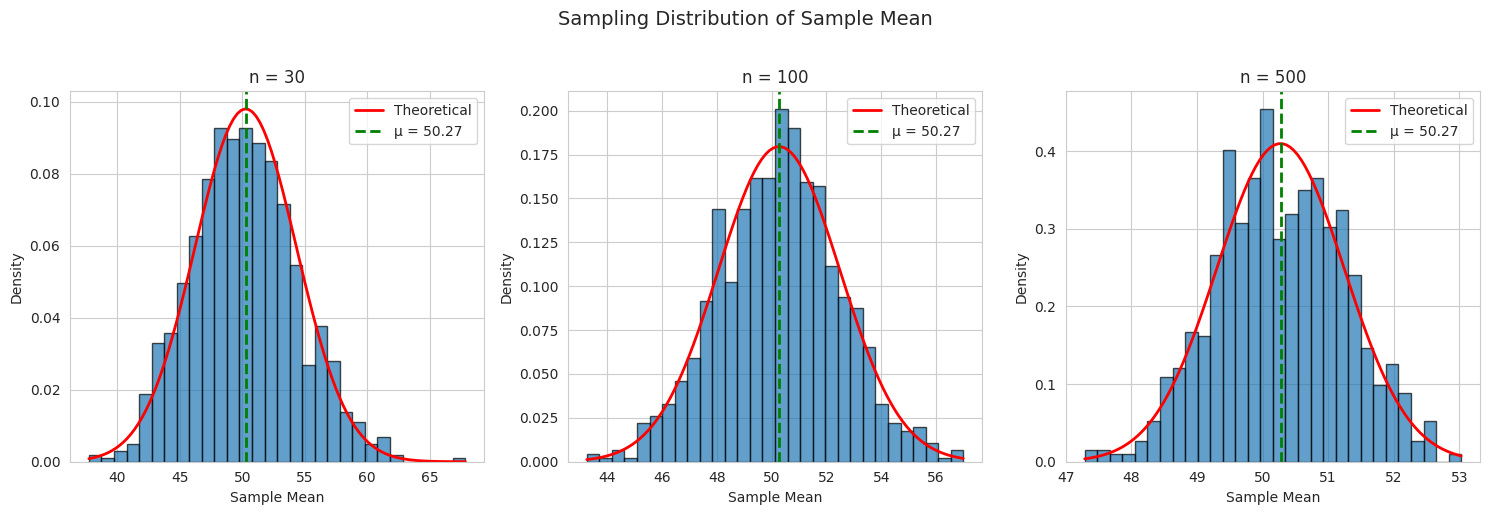

In [2]:
# 単純無作為抽出のシミュレーション
np.random.seed(123)

# Create population
N = 10000  # Population size
population = np.random.gamma(5, 10, N)  # Skewed distribution
population_mean = np.mean(population)
population_var = np.var(population, ddof=0)

print("単純無作為抽出")
print("="*50)
print(f"\n母集団サイズ: N = {N}")
print(f"母平均: μ = {population_mean:.2f}")
print(f"母分散: σ² = {population_var:.2f}")

# Sample with different sizes
sample_sizes = [30, 100, 500]
n_simulations = 1000

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, n in enumerate(sample_sizes):
    sample_means = []
    
    for _ in range(n_simulations):
        sample = np.random.choice(population, n, replace=False)
        sample_means.append(np.mean(sample))
    
    sample_means = np.array(sample_means)
    
    # Theoretical variance
    fpc = (N - n) / (N - 1)  # Finite population correction
    theoretical_var = population_var / n * fpc
    theoretical_se = np.sqrt(theoretical_var)
    
    print(f"\nn = {n}:")
    print(f"  標本平均の平均: {np.mean(sample_means):.2f}")
    print(f"  標本平均の標準誤差 (実測): {np.std(sample_means):.3f}")
    print(f"  標本平均の標準誤差 (理論): {theoretical_se:.3f}")
    
    # Plot
    axes[idx].hist(sample_means, bins=30, density=True, alpha=0.7, edgecolor='black')
    x = np.linspace(min(sample_means), max(sample_means), 100)
    axes[idx].plot(x, stats.norm.pdf(x, population_mean, theoretical_se), 
                   'r-', linewidth=2, label='Theoretical')
    axes[idx].axvline(population_mean, color='green', linestyle='--', 
                      linewidth=2, label=f'μ = {population_mean:.2f}')
    axes[idx].set_xlabel('Sample Mean', fontsize=10)
    axes[idx].set_ylabel('Density', fontsize=10)
    axes[idx].set_title(f'n = {n}', fontsize=12)
    axes[idx].legend()

plt.suptitle('Sampling Distribution of Sample Mean', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

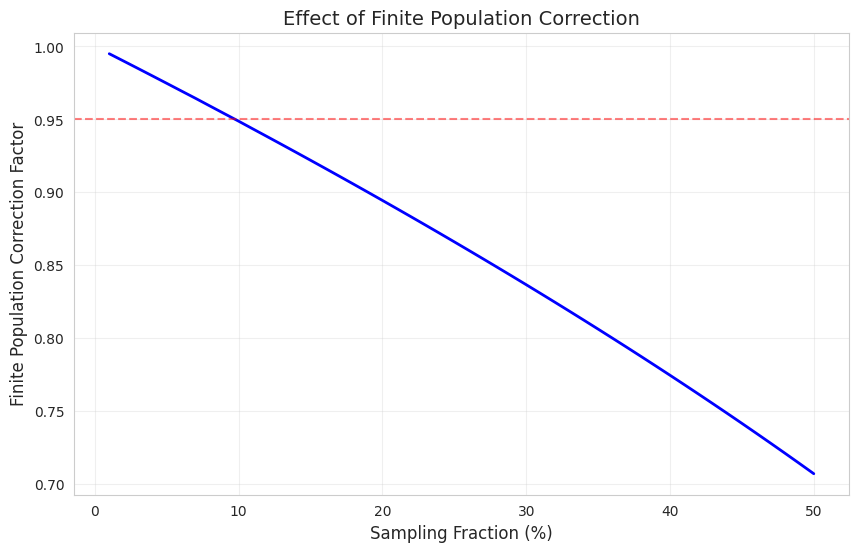

有限母集団修正 (FPC)

抽出率が小さい（< 5%）場合、FPCは1に近く無視できる
抽出率が大きい場合、FPCにより標準誤差は小さくなる


In [3]:
# 有限母集団修正の効果
sampling_fractions = np.linspace(0.01, 0.5, 50)
fpc_values = []

for f in sampling_fractions:
    n = int(f * N)
    fpc = np.sqrt((N - n) / (N - 1))
    fpc_values.append(fpc)

plt.figure(figsize=(10, 6))
plt.plot(sampling_fractions * 100, fpc_values, 'b-', linewidth=2)
plt.axhline(0.95, color='red', linestyle='--', alpha=0.5)
plt.xlabel('Sampling Fraction (%)', fontsize=12)
plt.ylabel('Finite Population Correction Factor', fontsize=12)
plt.title('Effect of Finite Population Correction', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

print("有限母集団修正 (FPC)")
print("="*50)
print("\n抽出率が小さい（< 5%）場合、FPCは1に近く無視できる")
print("抽出率が大きい場合、FPCにより標準誤差は小さくなる")

## 21.2 層化抽出

### 定義
母集団を互いに排他的な層（ストラータ）に分け、各層から独立に標本を抽出

### 層化推定量
$$\bar{y}_{st} = \sum_{h=1}^{H} W_h \bar{y}_h$$

ここで $W_h = N_h/N$ は層の重み

### 層化推定量の分散
$$V(\bar{y}_{st}) = \sum_{h=1}^{H} W_h^2 \frac{S_h^2}{n_h} \left(1 - \frac{n_h}{N_h}\right)$$

### 標本配分
1. **比例配分**: $n_h \propto N_h$
2. **ネイマン配分**: $n_h \propto N_h S_h$ （分散を最小化）

In [4]:
# 層化抽出のシミュレーション
np.random.seed(456)

# Create stratified population
# 3 strata with different means and variances
strata = [
    {'name': 'Stratum 1', 'N': 5000, 'mean': 30, 'sd': 5},
    {'name': 'Stratum 2', 'N': 3000, 'mean': 50, 'sd': 10},
    {'name': 'Stratum 3', 'N': 2000, 'mean': 80, 'sd': 15}
]

N_total = sum(s['N'] for s in strata)
populations = [np.random.normal(s['mean'], s['sd'], s['N']) for s in strata]

# Population mean
pop_mean = sum(s['N']/N_total * s['mean'] for s in strata)

print("層化抽出")
print("="*60)
print(f"\n母集団サイズ: N = {N_total}")
print(f"母平均: μ = {pop_mean:.2f}")

print(f"\n{'層':^15} {'N_h':>8} {'W_h':>8} {'μ_h':>8} {'σ_h':>8}")
print("-"*55)
for s, pop in zip(strata, populations):
    W = s['N'] / N_total
    print(f"{s['name']:^15} {s['N']:>8} {W:>8.3f} {s['mean']:>8} {s['sd']:>8}")

層化抽出

母集団サイズ: N = 10000
母平均: μ = 46.00

       層             N_h      W_h      μ_h      σ_h
-------------------------------------------------------
   Stratum 1        5000    0.500       30        5
   Stratum 2        3000    0.300       50       10
   Stratum 3        2000    0.200       80       15


In [5]:
# 配分方法の比較
n_total = 200  # Total sample size

def stratified_sample(populations, strata, allocation, n_total):
    """Perform stratified sampling with given allocation."""
    N_total = sum(s['N'] for s in strata)
    
    if allocation == 'proportional':
        n_h = [int(n_total * s['N'] / N_total) for s in strata]
    elif allocation == 'neyman':
        # Neyman allocation: n_h ∝ N_h * S_h
        total_NhSh = sum(s['N'] * s['sd'] for s in strata)
        n_h = [int(n_total * s['N'] * s['sd'] / total_NhSh) for s in strata]
    elif allocation == 'equal':
        n_h = [n_total // len(strata)] * len(strata)
    
    # Adjust for rounding
    n_h[-1] = n_total - sum(n_h[:-1])
    
    # Sample from each stratum
    samples = [np.random.choice(pop, nh, replace=False) 
               for pop, nh in zip(populations, n_h)]
    
    # Calculate stratified mean
    weights = [s['N'] / N_total for s in strata]
    y_st = sum(w * np.mean(sample) for w, sample in zip(weights, samples))
    
    return y_st, n_h

# Compare allocations
allocations = ['proportional', 'neyman', 'equal']
n_simulations = 1000

results = {}

for alloc in allocations:
    estimates = []
    for _ in range(n_simulations):
        y_st, n_h = stratified_sample(populations, strata, alloc, n_total)
        estimates.append(y_st)
    
    results[alloc] = {
        'estimates': estimates,
        'mean': np.mean(estimates),
        'se': np.std(estimates),
        'n_h': n_h
    }

print("\n配分方法の比較")
print("="*60)
print(f"\n{'方法':^15} {'n1':>6} {'n2':>6} {'n3':>6} {'平均':>10} {'SE':>10}")
print("-"*60)

for alloc in allocations:
    r = results[alloc]
    print(f"{alloc:^15} {r['n_h'][0]:>6} {r['n_h'][1]:>6} {r['n_h'][2]:>6} "
          f"{r['mean']:>10.3f} {r['se']:>10.3f}")

# Compare with SRS
all_pop = np.concatenate(populations)
srs_estimates = [np.mean(np.random.choice(all_pop, n_total, replace=False)) 
                 for _ in range(n_simulations)]

print(f"{'SRS':^15} {'-':>6} {'-':>6} {'-':>6} "
      f"{np.mean(srs_estimates):>10.3f} {np.std(srs_estimates):>10.3f}")


配分方法の比較

      方法            n1     n2     n3         平均         SE
------------------------------------------------------------
 proportional      100     60     40     45.944      0.647
    neyman          58     70     72     45.931      0.637
     equal          66     66     68     45.930      0.606
      SRS            -      -      -     45.890      1.527


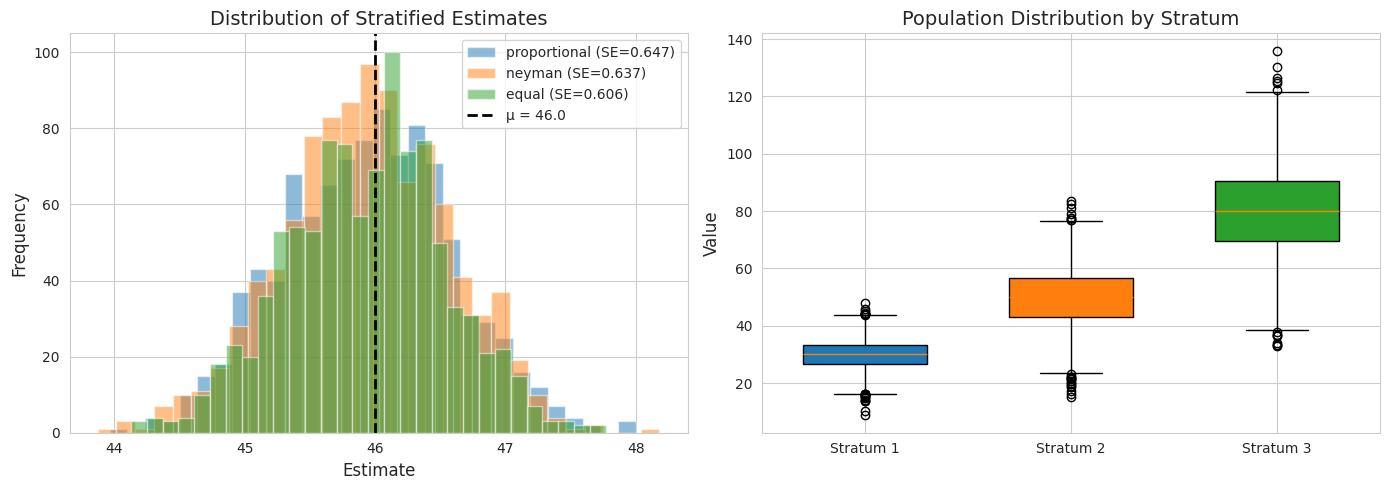

In [6]:
# 可視化
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of estimates
for alloc in allocations:
    axes[0].hist(results[alloc]['estimates'], bins=30, alpha=0.5, 
                 label=f"{alloc} (SE={results[alloc]['se']:.3f})")

axes[0].axvline(pop_mean, color='black', linestyle='--', linewidth=2, label=f'μ = {pop_mean:.1f}')
axes[0].set_xlabel('Estimate', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Distribution of Stratified Estimates', fontsize=14)
axes[0].legend()

# Population by strata
positions = []
for i, (pop, s) in enumerate(zip(populations, strata)):
    bp = axes[1].boxplot([pop], positions=[i], widths=0.6, patch_artist=True)
    bp['boxes'][0].set_facecolor(f'C{i}')

axes[1].set_xticks([0, 1, 2])
axes[1].set_xticklabels([s['name'] for s in strata])
axes[1].set_ylabel('Value', fontsize=12)
axes[1].set_title('Population Distribution by Stratum', fontsize=14)

plt.tight_layout()
plt.show()

## 21.3 クラスター抽出

### 定義
母集団をクラスター（集落）に分け、クラスターを標本単位として抽出

### 単純クラスター抽出
選ばれたクラスター内の全要素を調査

### 二段抽出
1段目: クラスターを抽出
2段目: 各クラスター内から要素を抽出

### 効率
- クラスター内が同質 → 効率低下
- クラスター内が異質 → 効率向上

In [7]:
# クラスター抽出のシミュレーション
np.random.seed(789)

# Create clustered population
n_clusters = 100
cluster_size = 50
N_total = n_clusters * cluster_size

# Cluster means (between-cluster variation)
cluster_means = np.random.normal(50, 10, n_clusters)

# Generate population
clusters = []
for mu in cluster_means:
    # Within-cluster variation
    cluster_data = np.random.normal(mu, 5, cluster_size)
    clusters.append(cluster_data)

population_clustered = np.concatenate(clusters)
pop_mean_clustered = np.mean(population_clustered)

print("クラスター抽出")
print("="*50)
print(f"\nクラスター数: {n_clusters}")
print(f"クラスターサイズ: {cluster_size}")
print(f"母集団サイズ: N = {N_total}")
print(f"母平均: μ = {pop_mean_clustered:.2f}")

# Compare cluster sampling with SRS
n_selected_clusters = 10
n_total_sample = n_selected_clusters * cluster_size  # Total sample size
n_simulations = 1000

# Cluster sampling
cluster_estimates = []
for _ in range(n_simulations):
    selected = np.random.choice(n_clusters, n_selected_clusters, replace=False)
    sample = np.concatenate([clusters[i] for i in selected])
    cluster_estimates.append(np.mean(sample))

# SRS with same sample size
srs_estimates = []
for _ in range(n_simulations):
    sample = np.random.choice(population_clustered, n_total_sample, replace=False)
    srs_estimates.append(np.mean(sample))

print(f"\n標本サイズ: n = {n_total_sample}")
print(f"\n{'方法':^20} {'平均':>10} {'SE':>10}")
print("-"*45)
print(f"{'Cluster Sampling':^20} {np.mean(cluster_estimates):>10.3f} {np.std(cluster_estimates):>10.3f}")
print(f"{'SRS':^20} {np.mean(srs_estimates):>10.3f} {np.std(srs_estimates):>10.3f}")
print(f"\n設計効果 (DEFF) = {np.var(cluster_estimates) / np.var(srs_estimates):.2f}")

クラスター抽出

クラスター数: 100
クラスターサイズ: 50
母集団サイズ: N = 5000
母平均: μ = 50.22

標本サイズ: n = 500

         方法                  平均         SE
---------------------------------------------
  Cluster Sampling       50.298      2.992
        SRS              50.252      0.456

設計効果 (DEFF) = 43.01


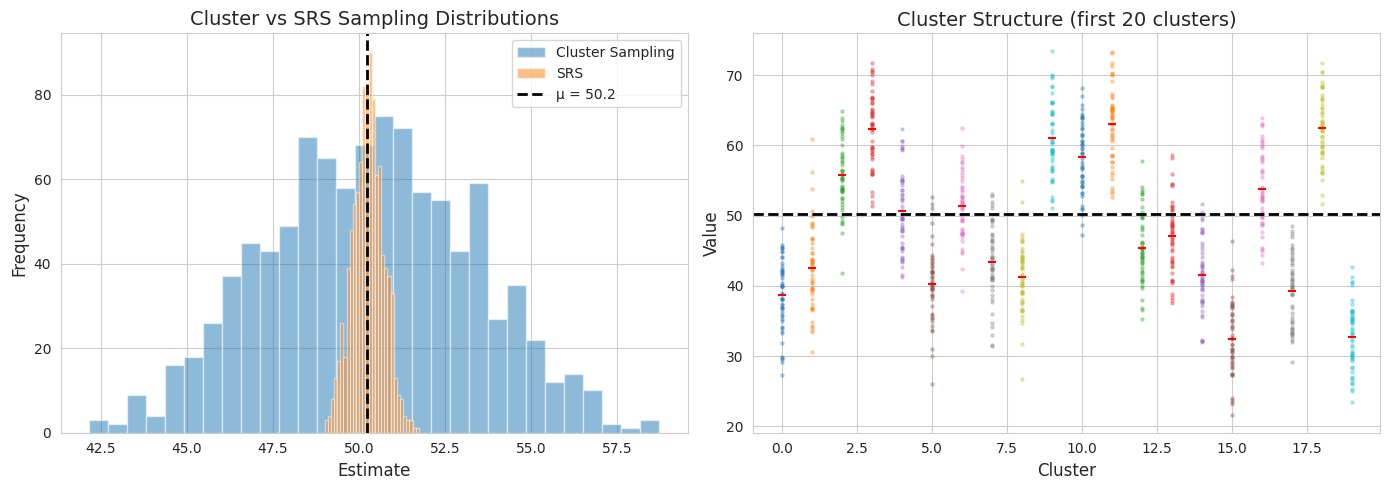

In [8]:
# 可視化
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of estimates
axes[0].hist(cluster_estimates, bins=30, alpha=0.5, label='Cluster Sampling')
axes[0].hist(srs_estimates, bins=30, alpha=0.5, label='SRS')
axes[0].axvline(pop_mean_clustered, color='black', linestyle='--', 
                linewidth=2, label=f'μ = {pop_mean_clustered:.1f}')
axes[0].set_xlabel('Estimate', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Cluster vs SRS Sampling Distributions', fontsize=14)
axes[0].legend()

# Cluster structure
for i in range(min(20, n_clusters)):
    axes[1].scatter([i]*cluster_size, clusters[i], alpha=0.3, s=5)
    axes[1].scatter([i], [np.mean(clusters[i])], color='red', s=30, marker='_')

axes[1].axhline(pop_mean_clustered, color='black', linestyle='--', linewidth=2)
axes[1].set_xlabel('Cluster', fontsize=12)
axes[1].set_ylabel('Value', fontsize=12)
axes[1].set_title('Cluster Structure (first 20 clusters)', fontsize=14)

plt.tight_layout()
plt.show()

## 21.4 比推定

### 定義
補助変数 $x$ を用いて主変数 $y$ を推定

### 比推定量
$$\hat{R} = \frac{\bar{y}}{\bar{x}}$$

母平均の推定:
$$\hat{\bar{Y}}_R = \hat{R} \cdot \bar{X} = \bar{y} \cdot \frac{\bar{X}}{\bar{x}}$$

### 分散
$$V(\hat{R}) \approx \frac{1}{\bar{X}^2} \left( S_y^2 + R^2 S_x^2 - 2R S_{xy} \right) \cdot \frac{1}{n}$$

In [9]:
# 比推定のシミュレーション
np.random.seed(111)

# Create correlated X and Y
N = 5000

# Auxiliary variable X (known for population)
X_pop = np.random.gamma(5, 20, N)
X_mean_pop = np.mean(X_pop)

# Study variable Y (correlated with X)
Y_pop = 0.8 * X_pop + np.random.normal(0, 10, N)
Y_mean_pop = np.mean(Y_pop)

# True ratio
R_true = Y_mean_pop / X_mean_pop

print("比推定")
print("="*50)
print(f"\n母集団サイズ: N = {N}")
print(f"母平均 X: {X_mean_pop:.2f}")
print(f"母平均 Y: {Y_mean_pop:.2f}")
print(f"真の比 R: {R_true:.4f}")
print(f"相関係数: {np.corrcoef(X_pop, Y_pop)[0,1]:.4f}")

# Compare ratio estimator with simple mean estimator
n = 100
n_simulations = 1000

simple_estimates = []
ratio_estimates = []

for _ in range(n_simulations):
    idx = np.random.choice(N, n, replace=False)
    x_sample = X_pop[idx]
    y_sample = Y_pop[idx]
    
    # Simple estimator
    simple_estimates.append(np.mean(y_sample))
    
    # Ratio estimator
    R_hat = np.mean(y_sample) / np.mean(x_sample)
    Y_ratio = R_hat * X_mean_pop
    ratio_estimates.append(Y_ratio)

print(f"\n標本サイズ: n = {n}")
print(f"\n{'推定法':^15} {'平均':>10} {'SE':>10} {'バイアス':>10}")
print("-"*50)
print(f"{'単純平均':^15} {np.mean(simple_estimates):>10.3f} {np.std(simple_estimates):>10.3f} "
      f"{np.mean(simple_estimates) - Y_mean_pop:>10.3f}")
print(f"{'比推定':^15} {np.mean(ratio_estimates):>10.3f} {np.std(ratio_estimates):>10.3f} "
      f"{np.mean(ratio_estimates) - Y_mean_pop:>10.3f}")

# Efficiency gain
efficiency = np.var(simple_estimates) / np.var(ratio_estimates)
print(f"\n効率向上: {efficiency:.2f}倍")

比推定

母集団サイズ: N = 5000
母平均 X: 99.69
母平均 Y: 79.84
真の比 R: 0.8009
相関係数: 0.9628

標本サイズ: n = 100

      推定法               平均         SE       バイアス
--------------------------------------------------
     単純平均           79.728      3.654     -0.115
      比推定           79.808      0.992     -0.035

効率向上: 13.58倍


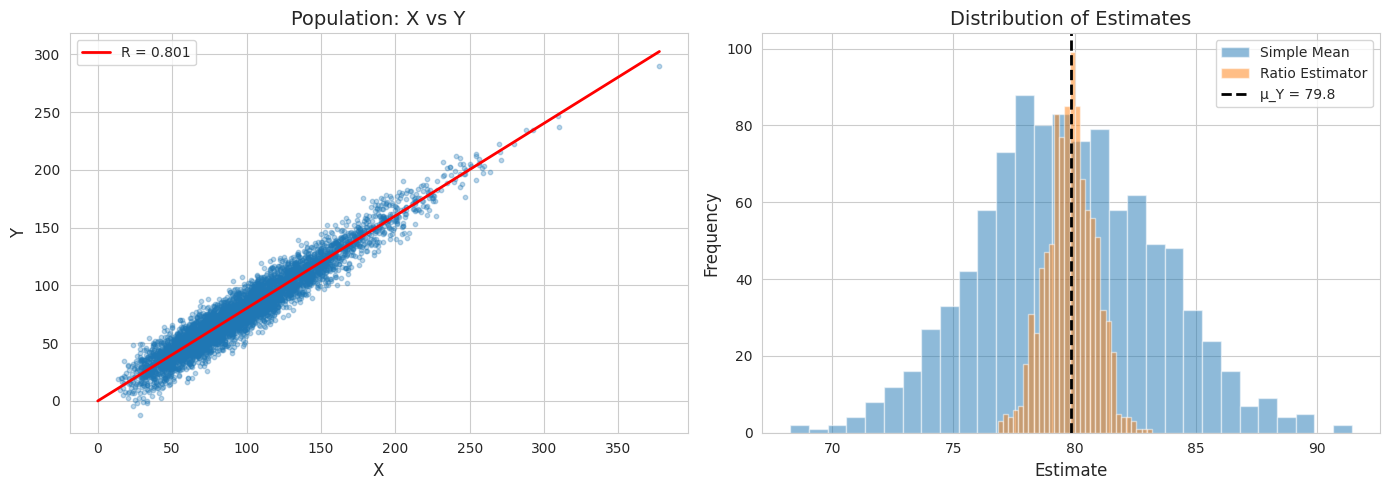

In [10]:
# 可視化
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# X vs Y scatter
axes[0].scatter(X_pop, Y_pop, alpha=0.3, s=10)
x_line = np.array([0, max(X_pop)])
axes[0].plot(x_line, R_true * x_line, 'r-', linewidth=2, label=f'R = {R_true:.3f}')
axes[0].set_xlabel('X', fontsize=12)
axes[0].set_ylabel('Y', fontsize=12)
axes[0].set_title('Population: X vs Y', fontsize=14)
axes[0].legend()

# Distribution of estimates
axes[1].hist(simple_estimates, bins=30, alpha=0.5, label='Simple Mean')
axes[1].hist(ratio_estimates, bins=30, alpha=0.5, label='Ratio Estimator')
axes[1].axvline(Y_mean_pop, color='black', linestyle='--', 
                linewidth=2, label=f'μ_Y = {Y_mean_pop:.1f}')
axes[1].set_xlabel('Estimate', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Distribution of Estimates', fontsize=14)
axes[1].legend()

plt.tight_layout()
plt.show()

## 21.5 標本誤差

### 標本誤差と非標本誤差
- **標本誤差**: 母集団の一部しか調べないことによる誤差
- **非標本誤差**: 測定誤差、回答誤差、無回答バイアス等

### 標本誤差の評価
$$SE(\bar{y}) = \sqrt{\frac{s^2}{n} \cdot \frac{N-n}{N}}$$

### 信頼区間
$$\bar{y} \pm t_{n-1, \alpha/2} \cdot SE(\bar{y})$$

### 必要標本サイズ
$$n = \frac{N \sigma^2}{(N-1)D + \sigma^2}$$

ここで $D = B^2/z_{\alpha/2}^2$, $B$ は許容誤差

In [11]:
# 標本サイズの決定
def required_sample_size(N, sigma, B, confidence=0.95):
    """Calculate required sample size for given margin of error."""
    z = stats.norm.ppf(1 - (1 - confidence) / 2)
    D = B**2 / z**2
    n = (N * sigma**2) / ((N - 1) * D + sigma**2)
    return int(np.ceil(n))

# Example
N = 10000
sigma = 20  # Estimated population SD

print("必要標本サイズの計算")
print("="*50)
print(f"\n母集団サイズ: N = {N}")
print(f"母標準偏差 (推定): σ = {sigma}")

print(f"\n{'許容誤差 B':>12} {'n (95% CI)':>12} {'n (99% CI)':>12}")
print("-"*40)

for B in [1, 2, 3, 5]:
    n_95 = required_sample_size(N, sigma, B, 0.95)
    n_99 = required_sample_size(N, sigma, B, 0.99)
    print(f"{B:>12} {n_95:>12} {n_99:>12}")

必要標本サイズの計算

母集団サイズ: N = 10000
母標準偏差 (推定): σ = 20

      許容誤差 B   n (95% CI)   n (99% CI)
----------------------------------------
           1         1333         2098
           2          370          623
           3          168          287
           5           62          106


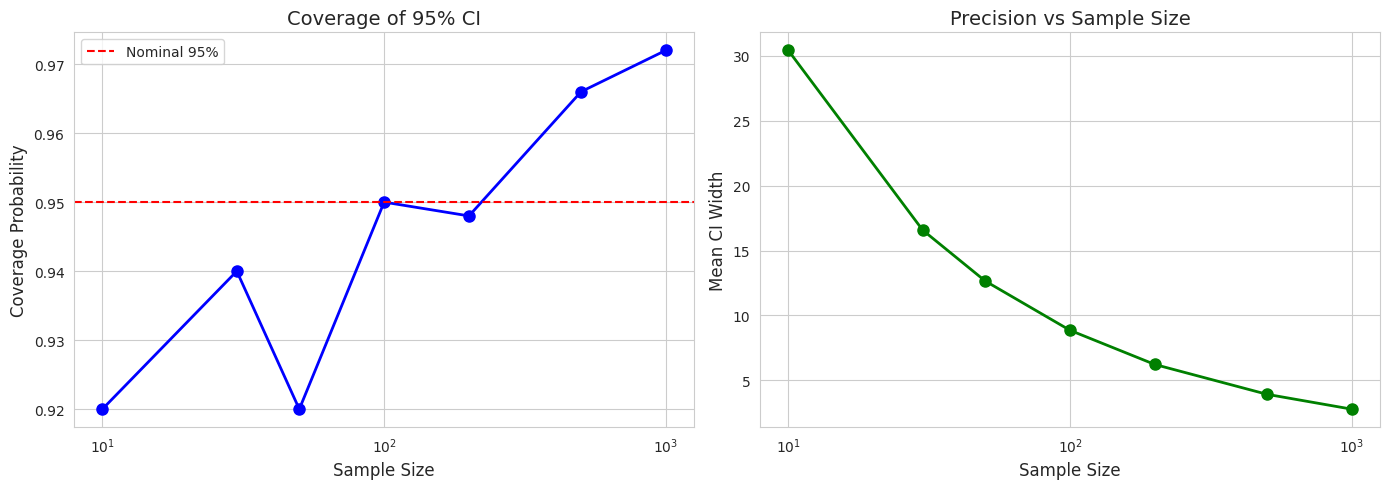

In [12]:
# 標本サイズと精度の関係
np.random.seed(222)

# Use previous population
sample_sizes = [10, 30, 50, 100, 200, 500, 1000]
n_simulations = 500

coverage_95 = []
mean_widths = []

for n in sample_sizes:
    covered = 0
    widths = []
    
    for _ in range(n_simulations):
        sample = np.random.choice(population, n, replace=False)
        y_bar = np.mean(sample)
        se = np.std(sample, ddof=1) / np.sqrt(n)
        
        # 95% CI
        t_val = stats.t.ppf(0.975, n-1)
        ci_lower = y_bar - t_val * se
        ci_upper = y_bar + t_val * se
        
        widths.append(ci_upper - ci_lower)
        
        if ci_lower <= population_mean <= ci_upper:
            covered += 1
    
    coverage_95.append(covered / n_simulations)
    mean_widths.append(np.mean(widths))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Coverage probability
axes[0].plot(sample_sizes, coverage_95, 'bo-', linewidth=2, markersize=8)
axes[0].axhline(0.95, color='red', linestyle='--', label='Nominal 95%')
axes[0].set_xlabel('Sample Size', fontsize=12)
axes[0].set_ylabel('Coverage Probability', fontsize=12)
axes[0].set_title('Coverage of 95% CI', fontsize=14)
axes[0].legend()
axes[0].set_xscale('log')

# CI width
axes[1].plot(sample_sizes, mean_widths, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('Sample Size', fontsize=12)
axes[1].set_ylabel('Mean CI Width', fontsize=12)
axes[1].set_title('Precision vs Sample Size', fontsize=14)
axes[1].set_xscale('log')

plt.tight_layout()
plt.show()

## 21.6 練習問題

### 問題1
母集団サイズ N=5000、母標準偏差 σ=50 のとき、平均の許容誤差を ±5 以内にするために必要な標本サイズを求めよ（95%信頼水準）。

### 問題2
以下の層化設計について、比例配分とネイマン配分の標本配分を求めよ（総標本サイズ n=200）。

| 層 | N_h | σ_h |
|---|-----|-----|
| 1 | 3000 | 10 |
| 2 | 2000 | 20 |
| 3 | 1000 | 30 |

### 問題3
クラスター抽出が単純無作為抽出より効率的になる条件を説明せよ。

In [13]:
# 問題1の解答
print("問題1: 必要標本サイズ")
print("="*50)

N = 5000
sigma = 50
B = 5
confidence = 0.95

n = required_sample_size(N, sigma, B, confidence)

print(f"\nN = {N}, σ = {sigma}, B = {B}, 信頼水準 = {confidence*100}%")
print(f"\n必要標本サイズ: n = {n}")

# Verify
z = stats.norm.ppf(0.975)
se = sigma / np.sqrt(n) * np.sqrt((N - n) / (N - 1))
me = z * se
print(f"\n検証: 標準誤差 = {se:.2f}, 許容誤差 = ±{me:.2f}")

問題1: 必要標本サイズ

N = 5000, σ = 50, B = 5, 信頼水準 = 95.0%

必要標本サイズ: n = 357

検証: 標準誤差 = 2.55, 許容誤差 = ±5.00


In [14]:
# 問題2の解答
print("問題2: 標本配分")
print("="*50)

strata_info = [
    {'name': '層1', 'N': 3000, 'sigma': 10},
    {'name': '層2', 'N': 2000, 'sigma': 20},
    {'name': '層3', 'N': 1000, 'sigma': 30}
]

N_total = sum(s['N'] for s in strata_info)
n_total = 200

# Proportional allocation
n_prop = [int(n_total * s['N'] / N_total) for s in strata_info]
n_prop[-1] = n_total - sum(n_prop[:-1])  # Adjust for rounding

# Neyman allocation
total_NhSh = sum(s['N'] * s['sigma'] for s in strata_info)
n_neyman = [int(n_total * s['N'] * s['sigma'] / total_NhSh) for s in strata_info]
n_neyman[-1] = n_total - sum(n_neyman[:-1])  # Adjust for rounding

print(f"\n総標本サイズ: n = {n_total}")
print(f"\n{'層':^8} {'N_h':>8} {'σ_h':>8} {'比例配分':>10} {'ネイマン配分':>12}")
print("-"*55)
for i, s in enumerate(strata_info):
    print(f"{s['name']:^8} {s['N']:>8} {s['sigma']:>8} {n_prop[i]:>10} {n_neyman[i]:>12}")

print(f"\nネイマン配分は分散の大きい層から多くサンプリングする")

問題2: 標本配分

総標本サイズ: n = 200

   層          N_h      σ_h       比例配分       ネイマン配分
-------------------------------------------------------
   層1        3000       10        100           60
   層2        2000       20         66           80
   層3        1000       30         34           60

ネイマン配分は分散の大きい層から多くサンプリングする


In [15]:
# 問題3の解答
print("問題3: クラスター抽出の効率性")
print("="*60)

print("""
【クラスター抽出がSRSより効率的になる条件】

クラスター抽出は通常SRSより効率が悪いが、以下の条件で改善:

1. クラスター内の異質性が高い（クラスター内変動が大きい）
   - 各クラスターが母集団全体を代表
   - 級内相関係数 (ICC) が小さいほど良い

2. クラスター間の同質性が高い（クラスター間変動が小さい）
   - どのクラスターを選んでも似た結果

3. コスト面での優位性
   - 移動コストが高い場合（地理的調査など）
   - サンプリングフレームが利用しやすい

【設計効果 (DEFF)】
DEFF = Var(クラスター) / Var(SRS)
DEFF ≈ 1 + (m - 1) × ICC

ここで m はクラスターサイズ、ICCは級内相関係数
DEFF < 1 のとき、クラスター抽出が効率的

【実際の使用】
統計的効率よりコスト効率で選ばれることが多い
""")

問題3: クラスター抽出の効率性

【クラスター抽出がSRSより効率的になる条件】

クラスター抽出は通常SRSより効率が悪いが、以下の条件で改善:

1. クラスター内の異質性が高い（クラスター内変動が大きい）
   - 各クラスターが母集団全体を代表
   - 級内相関係数 (ICC) が小さいほど良い

2. クラスター間の同質性が高い（クラスター間変動が小さい）
   - どのクラスターを選んでも似た結果

3. コスト面での優位性
   - 移動コストが高い場合（地理的調査など）
   - サンプリングフレームが利用しやすい

【設計効果 (DEFF)】
DEFF = Var(クラスター) / Var(SRS)
DEFF ≈ 1 + (m - 1) × ICC

ここで m はクラスターサイズ、ICCは級内相関係数
DEFF < 1 のとき、クラスター抽出が効率的

【実際の使用】
統計的効率よりコスト効率で選ばれることが多い



## ⚠️ よくある間違いと解決策

統計分析では、手法の前提条件を確認せずに適用してしまうことがよくあります。必ず前提を確認し、適切な手法を選択しましょう。

---

## 📝 理解度チェック

この章で学んだ内容を振り返り、重要な概念を自分の言葉で説明できるか確認しましょう。

---

## 📚 まとめ

お疲れ様でした！この章で学んだ手法は、実際のデータ分析で頻繁に使われます。実データで試して理解を深めましょう。

---